<a href="https://colab.research.google.com/github/odenas/modern_ml_hws/blob/main/Copy_of_hw1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Homework 1 - Introduction to Linear Algebra + PyTorch

This homework is aimed to familiarize you with some of the basic linear algebra operations we covered in class, as well as how to implement these functions and more in PyTorch.

As before, make a copy of the assignment to your drive, add your mugrade key, and then run the cells below to get started.

In [ ]:
### Run this cell to download and installs the necessary modules for the homework
!pip install --upgrade --no-deps git+https://github.com/locuslab/mugrade.git
!wget -nc https://raw.githubusercontent.com/modernaicourse/hw1/refs/heads/main/hw1_tests.py

import os
import mugrade
import torch

from hw1_tests import images, test_classify_zero_one, submit_classify_zero_one, \
    test_vector_add, submit_vector_add, \
    test_vector_inner_product, submit_vector_inner_product, \
    test_matrix_vector_product_1, submit_matrix_vector_product_1, \
    test_matrix_vector_product_2, submit_matrix_vector_product_2, \
    test_vector_matrix_product_2, submit_vector_matrix_product_2, \
    test_matmul_1, submit_matmul_1, \
    test_matmul_2, submit_matmul_2, \
    test_matmul_3, submit_matmul_3, \
    test_batch_matmul, submit_batch_matmul, \
    test_block_matmul, submit_block_matmul

os.environ["MUGRADE_HW"] = "Homework 1"
os.environ["MUGRADE_KEY"] = "" ### Your key here

  Cloning https://github.com/locuslab/mugrade.git to /tmp/pip-req-build-z4wnoo5h
  Running command git clone --filter=blob:none --quiet https://github.com/locuslab/mugrade.git /tmp/pip-req-build-z4wnoo5h
  Resolved https://github.com/locuslab/mugrade.git to commit d79da78488a01d688f7e8d32bef008bfee27af5b
  Preparing metadata (setup.py) ... done
  Created wheel for mugrade: filename=mugrade-1.3-py3-none-any.whl size=4046 sha256=4169dd34d15936e4bbdd1d0f330b4faaab5223fde989bdffc8d586b93681b7a6
  Stored in directory: /tmp/pip-ephem-wheel-cache-oodgw085/wheels/34/d1/ce/8718af824354e197dbffca129b7b45c76dc4313b91b56b832c
Successfully built mugrade
--2026-02-06 05:41:52--  https://raw.githubusercontent.com/modernaicourse/hw1/refs/heads/main/hw1_tests.py
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, 

100%|██████████| 9.91M/9.91M [00:00<00:00, 39.1MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.14MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 2.51MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 7.40MB/s]


### Problem 1: "Classical" programming for digit classification

This course deals primarily with machine learning approaches, but it's worth emphasizing that you _can_ try to approach many of the problems you'll want to solve with machine learning with traditional programming approaches as well.  In this problem, you should experiment with developing a "manual" classifier between images of digits in the MNIST dataset, which will be the first machine learning mode you'll develop during the later assignments.  Specifically, you'll want to implement the following function `classify_zero_one` to classify between images of zeros and ones in the MNIST dataset.  Try to think intuitively about features that might distinguish between zeros and ones, and if possible, try not to look at any statistics from the actual dataset (i.e., average values of the images, or anything like that).

You can use the `images` dataset loaded above from the `hw1_tests.py` function (specifically the `images.data` and `images.targets` fields, which have been limited to just include the 0/1 images) to help you develop your code.


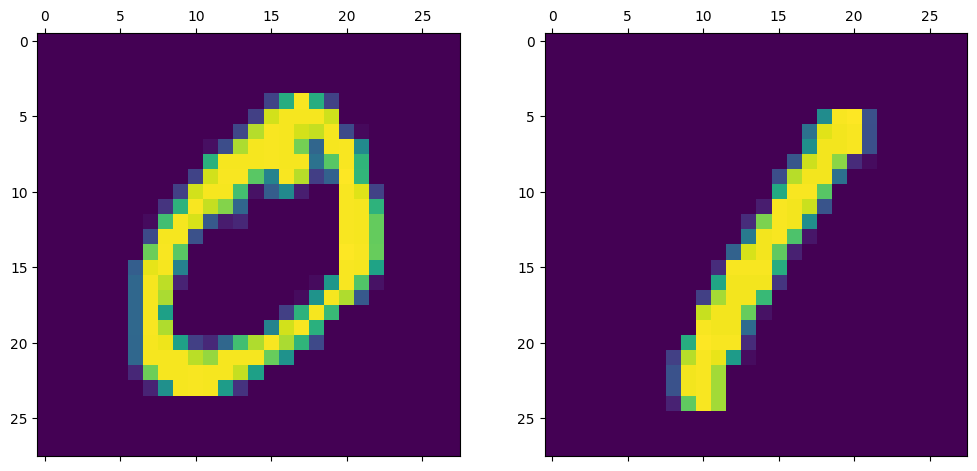

In [ ]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(12, 6))
ax[0].matshow(images.data[0])
ax[1].matshow(images.data[1])

In [ ]:
# you may want to leave this commented until you are ready to test, since it
# takes a few seconds to run local tests
@mugrade.local_tests
def classify_zero_one(image):
    """
    Classify a 28x28 pixel image as either a zero or one.

    Input:
        image : Tensor - 2D tensor storing grayscale pixel values of the image,
                         with each element a real-valued number in [0,1]
    Output:
        integer : 0 or 1
    """
    ### BEGIN YOUR CODE
    hslice = image[10:20, :]
    center = hslice[:, 14]
    return int(center.sum() > 5)
    ### END YOUR CODE

# from collections import Counter
# n = 100
# preds = [(classify_zero_one(images.data[i]), images.targets[i].item())
#             for i in range(n)]
# counts = Counter(preds)
# accuracy = (counts[(0,0)] + counts[(1,1)])/n
# #accuracy
# counts

# import pandas as pd
# x = images.data[0:100]
# y = images.targets[0:100].numpy()
# pd.DataFrame(
#     {"y": y, "y_hat": [int(classify_zero_one(im)) for im in x]}
# ).assign(acc=lambda x: x.y == x.y_hat).acc.mean()
#classify_zero_one(images.data[0])

Mugrade: Running local tests for function classify_zero_one():...
test_classify_zero_one
PASSED


### Problem 2: Vector Addition

In the remainder of this assignment, you're going to implement a wide variety of simple linear algebra operators, _without_ using any of the build-in tensor addition or matrix multiplication operators.  Your code should also throw assertion errors if any of the sizes do not match was it allowed for the given operation (i.e., you should be calling assert() to check that the sizes are correct).  Instead, you should use explicit for loops and element-by-element assignment/operations to implement your function.  You can also create new vectors of the right size as your return variable, etc.

First implement a simple vector addition function that adds two vectors together, $x,y \in \mathbb{R}^n$.  Note that it is ok if this only works when provided with vectors, i.e., 1D tensors.

In [ ]:
@mugrade.local_tests
def vector_add(x,y):
    """
    Add two vectors x and y, _without_ using the built-in addition of torch.
    Instead, you need to manually iterate through the elements of x and y and
    add them together. The function should throw an AssertionError, via
    calling assert(), if the vectors are not the proper size to add together.

    Input:
        x : 1D torch.Tensor - first term to add
        y : 1D torch.Tensor - second term to add

    Output:
        return 1D torch.Tensor - sum of x + y

    """
    ### BEGIN YOUR CODE
    assert len(x.shape) == 1
    assert x.shape == y.shape

    res = []
    for i in range(x.shape[0]):
        res.append(x[i] + y[i])
    return torch.tensor(res)
    ### END YOUR CODE


Mugrade: Running local tests for function vector_add():...
test_vector_add
PASSED


### Problem 3: Vector inner product

Now implement the vector inner product.  I.e., for two vectors $x, y \in \mathbb{R}^n$, return the inner product
$$\langle x,y \rangle \equiv x^T y = \sum_{i=1}^n x_i y_i.$$

As before, don't use any PyTorch functions that compute a matrix multiplication or inner product directly, but do it all with for loops.

In [ ]:
@mugrade.local_tests
def vector_inner_product(x,y):
    """
    Compute the inner product between two vectors x and y, _without_ using the
    matrix multiplication operator '@' (or any similar PyTorch function). The
    function should throw an AssertionError if the vectors are not the proper
    size.

    Input:
        x : 1D torch.Tensor - first term to add
        y : 1D torch.Tensor - second term to add

    Output:
        return float - inner product <x,y>
    """
    ### BEGIN YOUR CODE
    assert len(x.shape) == 1
    assert x.shape == y.shape, f"{x.shape} != {y.shape}"

    res = 0.0
    for i in range(x.shape[0]):
        res += float(x[i] * y[i])
    return res
    ### END YOUR CODE

Mugrade: Running local tests for function vector_inner_product():...
test_vector_inner_product
PASSED


### Problem 4: Matrix-vector product approach #1

Write a routine that computes the matrix-vector product $Ax$ for $A \in \mathbb{R}^{m \times n}$ and $x \in \mathbb{R}^n$.  This version should compute each entry of the resuting vector using the inner product between rows of $A$ and the vector $x$, i.e., shown graphically this would be
$$
Ax = \left [ \begin{array}{ccc}
\;\text{—} & a^T_1 & \text{—}\; \\
\;\text{—} & a^T_2 & \text{—}\; \\
& \vdots & \\
\;\text{—} & a^T_m & \text{—}\;
\end{array} \right ] \left [ \begin{array}{c}\mid \\ x \\ \mid \end{array}  \right ] = \left [ \begin{array}{c} a^T_1 x \\ a^T_2 x \\ \vdots \\ a^T_m x \end{array} \right].
$$

Only make use of the above-implemented `vector_inner_product()` function you implemetned above for this routine, i.e., no other operations on the tensors.

In [ ]:
@mugrade.local_tests
def matrix_vector_product_1(A,x):
    """
    Compute the matrix vector product Ax _without_ using the matrix
    multiplication operator @ or any related function. In this variant
    implement the output as the inner product of each row of A with
    the vector x (i.e., only make use of the vector_inner_product function).
    Be sure to throw AssertionErrors if the product is not valid.

    Input:
        A : 2D torch.Tensor - m x n matrix A
        x : 1D torch.Tensor - vector x with n elements

    Output:
        return 1D torch.Tensor - vector Ax with m elements
    """
    ### BEGIN YOUR CODE
    assert len(A.shape) == 2
    m, n = A.shape
    assert len(x.shape) == 1
    assert x.shape[0] == n

    res = []
    for i in range(m):
        res.append(vector_inner_product(A[i,:], x))
    return torch.tensor(res)
    ### END YOUR CODE

Mugrade: Running local tests for function matrix_vector_product_1():...
test_matrix_vector_product_1
PASSED


### Problem 5: Matrix-vector product approach #2

Write a routine that computes the matrix-vector product $Ax$ for $A \in \mathbb{R}^{m \times n}$ and $x \in \mathbb{R}^n$.  This version should compute the result as a linear combination of the columns of $A$ with coefficients given by the entries of $x_i$, i.e., shows graphically this would be
$$
Ax = \left [ \begin{array}{cccc} \mid & \mid & & \mid \\
a_1 & a_2 & \cdots & a_n \\
\mid & \mid & & \mid \end{array} \right ]
\left [ \begin{array}{c} x_1 \\ x_2 \\ \vdots \\ x_n \end{array}\right ] =
\left [ \begin{array}{c} \mid \\ a_1 \\ \mid \end{array} \right ] x_1 +
\left [ \begin{array}{c} \mid \\ a_2 \\ \mid \end{array} \right ] x_2 + \ldots +
\left [ \begin{array}{c} \mid \\ a_n \\ \mid \end{array} \right ] x_n
$$

Only make use of the above-implemented `vector_add()` function to implement your solution (plus of course creating vectors to return, etc).  It is also ok to multiply a vector by a scalar, i.e., the code `c*y` where `c` is a vector and `y` is a real-valued scalar.

In [ ]:
@mugrade.local_tests
def matrix_vector_product_2(A,x):
    """
    Compute the matrix vector product Ax _without_ using the matrix
    multiplication operator @ or any related function.  In this variant
    implement the output as a linear combination of the columns of A with
    coefficients given by the entries of x (and only make use of the
    vector_add function). Be sure to throw AssertionErrors if the sizes do
    not allow for a valid product

    Input:
        A : 2D torch.Tensor - m x n matrix A
        x : 1D torch.Tensor - vector x with n elements

    Output:
        return 1D torch.Tensor - vector Ax with m elements
    """
    ### BEGIN YOUR CODE
    assert len(A.shape) == 2
    m, n = A.shape
    assert len(x.shape) == 1
    assert x.shape[0] == n
    res = torch.zeros(m)
    for i in range(n):
        res = vector_add(res, A[:,i]*x[i])
    return res
    ### END YOUR CODE

# A = torch.tensor([
#     [1, 2, 3],
#     [4, 5, 6]
# ]) # 2x3
# x = torch.tensor([1, 2, 3])
# res = torch.zeros(2)
# res += A[:,0] * x[0]
# res

Mugrade: Running local tests for function matrix_vector_product_2():...
test_matrix_vector_product_2
PASSED


### Problem 6: Vector-matrix product approach #2

Write a routine that function that computes the vector-Matrix product $x^TA$ for $A \in \mathbb{R}^{m \times n}$ and $x \in \mathbb{R}^m$. In keeping with PyTorch convention (i.e., not differentiating between column and row vectors), this should return a 1D tensor representing the resulting row vector.  

This version should compute the result as a linear combination of the rows of $A$ with coefficients given by the entries of $x_i$, i.e., shows graphically this would be

$$
\begin{aligned}
x^T A & =
\left[ \begin{array}{cccc} x_1 & x_2 & \ldots & x_m \end{array} \right]
\left[ \begin{array}{ccc}
\;\text{—} & a^T_1 & \text{—}\; \\
\;\text{—} & a^T_2 & \text{—}\; \\
& \vdots & \\
\;\text{—} & a^T_m & \text{—}\;
\end{array} \right] \\ & =
x_1 \left[ \begin{array}{ccc} \;\text{—} & a^T_1 & \text{—}\; \end{array} \right] +
x_2 \left[ \begin{array}{ccc} \;\text{—} & a^T_2 & \text{—}\; \end{array} \right] + \ldots +
x_m \left[ \begin{array}{ccc} \;\text{—} & a^T_m & \text{—}\; \end{array} \right]
\end{aligned}
$$

Only make use of the above-implemented `vector_add()` function to implement your solution, with the same caveats as in the previous problem.

In [ ]:
@mugrade.local_tests
def vector_matrix_product_2(x,A):
    """
    Compute the vector Matrix product x^T A _without_ using the matrix
    multiplication operator @ or any related function.  In this variant
    implement the output as a linear combination of the rows of A with
    coefficients given by the entries of x (and only make use of the
    vector_add function).  Note that, in keeping with PyTorch convention (of
    not differentiating between row and column vectors), x will just be an
    vector (1D tensor) with m elements, and the output should be a vector (1D
    Tensor) with n elements. Be sure to throw AssertionErrors if the sizes do
    not allow for a valid product.

    Input:
        A : 2D torch.Tensor - m x n matrix A
        x : 1D torch.Tensor - vector x with m elements

    Output:
        return 1D torch.Tensor - vector x^T A with n elements
    """
    ### BEGIN YOUR CODE
    assert len(A.shape) == 2
    m, n = A.shape
    assert len(x.shape) == 1
    assert x.shape[0] == m
    res = torch.zeros(n)

    for i in range(m):
        res = vector_add(res, x[i]*A[i])
    return res
    ### END YOUR CODE

Mugrade: Running local tests for function vector_matrix_product_2():...
test_vector_matrix_product_2
PASSED


### Problem 7: Matrix-matrix multiplication approach #1

Write a matrix-matrix multiplication function, again without using any built-in operators.  For $A \in \mathbb{R}^{m \times n}$ and $B \in \mathbb{R}^{m \times p}$, this version should compute each element $(AB)_{ij}$ as the inner product of the $i$th row of $A$ and the $j$th column of $B$. Depicted graphically, this would be the breakdown

$$
AB =
\left[ \begin{array}{ccc}
\;\text{—} & a^T_1 & \text{—}\; \\
\;\text{—} & a^T_2 & \text{—}\; \\
& \vdots & \\
\;\text{—} & a^T_m & \text{—}\;
\end{array} \right]
\left[ \begin{array}{cccc}
| & | & & | \\
b_1 & b_2 & \cdots & b_p \\
| & | & & |
\end{array} \right]
=
\left[ \begin{array}{cccc}
a_1^T b_1 & a_1^T b_2 & \cdots & a_1^T b_p \\
a_2^T b_1 & a_2^T b_2 & \cdots & a_2^T b_p \\
\vdots & \vdots & \ddots & \vdots \\
a_m^T b_1 & a_m^T b_2 & \cdots & a_m^T b_p
\end{array} \right]
$$

With all the same caveats as before, this implementation should only use the function `vector_inner_product()` that you implemented above.


In [ ]:
@mugrade.local_tests
def matmul_1(A,B):
    """
    Compute the matrix matrix multiplication AB without using the @ operator.
    In this variant, compute each entry of the matrix product as the inner
    product of a row of A and a column of B (i.e., using the
    vector_inner_product function). Be sure to throw AssertionErrors if the
    sizes of the matrices do not make for a valid product.


    Input:
        A : 2D torch.Tensor - m x n matrix A
        B : 2D torch.Tensor - n x p matrix B

    Output:
        return 2D torch.Tensor - m x p matrix equal to the product AB
    """
    ### BEGIN YOUR CODE
    assert len(A.shape) == 2
    m, n = A.shape
    assert len(B.shape) == 2
    assert B.shape[0] == n
    n, p = B.shape

    res = torch.zeros(m, p)
    for i in range(m):
        for j in range(p):
            res[i, j] = vector_inner_product(A[i], B[:,j])
    return res
    ### END YOUR CODE


Mugrade: Running local tests for function matmul_1():...
test_matmul_1
PASSED


### Problem 8: Matrix-matrix multiplication approach #2

Write another matrix multiplication implemention. For $A \in \mathbb{R}^{m \times n}$ and $B \in \mathbb{R}^{m \times p}$, this version should compute the $i$th column of $AB$ as the matrix-vector product between $A$ and $i$th column of $B$. Depicted graphically, this would be the breakdown
$$
AB =
A
\left [ \begin{array}{cccc} \mid & \mid & & \mid \\
b_1 & b_2 & \cdots & b_p \\
\mid & \mid & & \mid \end{array} \right ]
=
\left [ \begin{array}{cccc} \mid & \mid & & \mid \\
A b_1 & A b_2 & \cdots & A b_p \\
\mid & \mid & & \mid \end{array} \right ]
$$

With all the same caveats as before, this implementation should only use the function `matrix_vector_product_1()` (or `matrix_vector_product_2()`) that you implemented above.


In [ ]:
@mugrade.local_tests
def matmul_2(A,B):
    """
    Compute the matrix matrix multiplication AB without using the @ operator.
    In this variant, compute the ith _column_ of the matrix product as the
    matrix-vector product of A and the ith column of B (i.e., using only the
    function matrix_vector_product_1 or matrix_vector_product_2). Be sure to
    throw AssertionErrors if the sizes of the matrices do not make for a valid
    product.

    Input:
        A : 2D torch.Tensor - m x n matrix A
        B : 2D torch.Tensor - n x p matrix B

    Output:
        return 2D torch.Tensor - m x p matrix equal to the product AB
    """
    ### BEGIN YOUR CODE
    assert len(A.shape) == 2
    m, n = A.shape
    assert len(B.shape) == 2
    assert B.shape[0] == n
    n, p = B.shape

    res = torch.zeros(m, p)
    for i in range(p):
        res[:, i] = matrix_vector_product_1(A, B[:, i])
    return res
    ### END YOUR CODE

Mugrade: Running local tests for function matmul_2():...
test_matmul_2
PASSED


### Problem 9: Matrix-matrix multiplication approach #3

Finally, write one last matrix multiplication implementation. For $A \in \mathbb{R}^{m \times n}$ and $B \in \mathbb{R}^{m \times p}$, this version should compute the $i$th row of $AB$ as the vector-matrix product between the $i$th row of $A$ and $B$. This would be the breakdown
$$
AB =
\left [ \begin{array}{ccc}
\;\text{—} & a^T_1 & \text{—}\; \\
\;\text{—} & a^T_2 & \text{—}\; \\
& \vdots & \\
\;\text{—} & a^T_m & \text{—}\;
\end{array} \right ] B =
\left [ \begin{array}{ccc}
\;\text{—} & a^T_1 B & \text{—}\; \\
\;\text{—} & a^T_2 B & \text{—}\; \\
& \vdots & \\
\;\text{—} & a^T_m B & \text{—}\;
\end{array} \right ]
$$


With all the same caveats as before, this implementation should only use the function `vector_matrix_product_2()` that you implemented above.


In [ ]:
@mugrade.local_tests
def matmul_3(A,B):
    """
    Compute the matrix matrix multiplication AB without using the @ operator.
    In this variant, compute the ith _row_ of the matrix product as the
    vector-matrix product of the ith row A and B (i.e., using only the
    function vector_matrix_product_2). Be sure to throw AssertionErrors if the
    sizes of the matrices do not make for a valid product.

    Input:
        A : 2D torch.Tensor - m x n matrix A
        B : 2D torch.Tensor - n x p matrix B

    Output:
        return 2D torch.Tensor - m x p matrix equal to the product AB
    """
    ### BEGIN YOUR CODE
    assert len(A.shape) == 2
    m, n = A.shape
    assert len(B.shape) == 2
    assert B.shape[0] == n
    n, p = B.shape

    res = torch.zeros(m, p)
    for i in range(m):
        res[i] = vector_matrix_product_2(A[i], B)
    return res
    ### END YOUR CODE

Mugrade: Running local tests for function matmul_3():...
test_matmul_3
PASSED


### Problem 10: Batch matrix multiplication

In this problem, you will implement batch matrix multiplication.  Consider two ND PyTorch tensors of the dimensions $A \in \mathbb{R}^{n_1 \times n_2 \times \ldots \times n_d}$ $B \in \mathbb{R}^{m_1 \times m_2 \times \ldots \times m_d}$ with the same sizes on all but the last two dimensions
$$ n_i = m_i, \; i=1,\ldots,d-2$$
and the last two dimensions properly sized for a matrix multiplication
$$n_i = m_{i-1}.$$
In this case implement a batched version of matrix multiplication that iterates over all the leading $d-2$ dimensions and performs a matrix multiplication of the corresponding entries.  The function should throw an AssertionError if any of the sizes do not match.

You should still not use the PyTorch matrix multiplication operator, but instead call one of the `matmul()` functions you implemented above (it doesn't really matter which one).

In [ ]:
@mugrade.local_tests
def batch_matmul(A,B):
    """
    Implement batch matrix multiplication between 2 tensors A and B by
    iterating over all the leading dimensions of A and B (all dimensions other
    than the last two), and performing a matrix multiplication over the last
    two dimensions. A and B must be sized so that their leading dimensions are
    all the same, and the last two dimensions are sized for a valid matrix
    multiplication.

    Inputs:
        A : torch.Tensor - ND tensor with trailing dimensions (..., m, n)
        B : torch.Tensor - ND tensor with trailing dimensions (..., n, p)

    Output:
        return torch.Tensor - ND tensor with tailing dimensions (..., m, p)
                              containing all matrix multiplications of the
                              corresponding entries.
    """
    ### BEGIN YOUR CODE
    assert len(A.shape) == len(B.shape)
    d = len(A.shape)
    for i in range(d-2):
        assert A.shape[i] == B.shape[i]
    assert A.shape[d-1] == B.shape[d-2]
    if d == 2:
        return matmul_3(A, B)
    return torch.stack([batch_matmul(A[i], B[i]) for i in range(A.shape[0])], 0)
    ### END YOUR CODE

# A1 = [
#     [1, 2, 3, 4],
#     [5, 6, 7, 8],
#     [9, 0, 1, 2]
# ]
# A2 = [
#     [1, 2, 3, 4],
#     [5, 6, 7, 8],
#     [9, 0, 1, 2]
# ]

# B1 = [
#     [1, 2, 3, 4, 5],
#     [5, 6, 7, 8, 9],
#     [9, 0, 1, 2, 3],
#     [3, 4, 5, 6, 7]
# ]
# B2 = [
#     [1, 2, 3, 4, 5],
#     [5, 6, 7, 8, 9],
#     [9, 0, 1, 2, 3],
#     [2, 3, 4, 5, 6]
# ]

# A = torch.tensor([A1, A2])
# B = torch.tensor([B1, B2])
# A.shape, B.shape, batch_matmul(A, B).shape

Mugrade: Running local tests for function batch_matmul():...
test_batch_matmul
PASSED


### Problem 11: Block matrix multiplication
In this last question, you'll implement a "blocked" form of matrix multiplication.  Although we defined matrix multiplication in terms of the individual scalar entries of a matrix, it can also be defined by operating on subblocks of the matrices.  Specifically for an matrix $A \in \mathbb{R}^{4m \times 4n}$ we can define $A_{ij} \in \mathbb{R}^{4 \times 4}$ to be a _subblock_ of the matrix, and similarly for the matrix $B \in \mathbb{R}^{4n \times 4p}$.  Then the corresponding $4 \times 4$ subblock of the matrix product $AB$ can be computed as
$$ (AB)_{ij} = \sum_{k=1}^n A_{ik} B_{kj} $$
analogous to the usual definition of matrix multiplication, but with $A_{ik} B_{kj}$ now being a matrix product.

In practice, techniques like this (with proper memory layouts, which we don't cover here) are how one writes fast matrix multiplication primitives on GPUs (where e.g., so-called "tensor cores" actually exactly perform 4x4 matrix multiplication).

Implement the `block_matmul` function below.  You should _only_ call the `add_matmul_44()` function in your implementation. You should check to ensure that the matrices form a valid matrix multiplication, and that they are all divisible by 4.

In [ ]:
def add_matmul_44(Z,A,B):
    """
    Simulate a "fast" 4x4 matrix multiplication and in-place addition to Z:
        Z += AB
    """
    assert(Z.shape == (4,4) and A.shape == (4,4) and B.shape == (4,4))
    for i in range(4):
        for j in range(4):
            Z[i,j] += A[i,0]*B[0,j] + A[i,1]*B[1,j] + A[i,2]*B[2,j] + A[i,3]*B[3,j]

In [ ]:
@mugrade.local_tests
def block_matmul(A,B):
    """
    Implement a block matrix multiplication to compute the matrix-matrix
    product AB.  You should use the formula above, and also assert that that
    matrices are the proper shapes (and have dimensions that are multiples of
    4). Use only the matmul_44 call.
    """
    ### BEGIN YOUR CODE
    assert len(A.shape) == 2
    m, n = A.shape
    assert len(B.shape) == 2
    assert B.shape[0] == n
    n, p = B.shape
    assert m % 4 == 0
    assert n % 4 == 0
    assert p % 4 == 0

    res = torch.zeros(m, p)
    for i in range(m // 4):
        for j in range(p // 4):
            for k in range(n // 4):
                # print(f"({i*4}:{(i+1)*4}, {j*4}:{(j+1)*4}), ({i*4}:{(i+1)*4}, {k*4}:{(k+1)*4}) --> (({k*4}:{(k+1)*4}, {j*4}:{(j+1)*4}))")
                add_matmul_44(res[i*4:(i+1)*4,j*4:(j+1)*4],
                              A[i*4:(i+1)*4,k*4:(k+1)*4],
                              B[k*4:(k+1)*4,j*4:(j+1)*4])
    return res
    ### END YOUR CODE
# A = torch.cat(
#     [torch.cat([torch.ones(4, 4)*1, torch.ones(4, 4)*2], dim=1),
#      torch.cat([torch.ones(4, 4)*3, torch.ones(4, 4)*4], dim=1)], dim=0
# )
# B = torch.cat([torch.ones(4, 4)*1, torch.ones(4, 4)*2], dim=0)
# block_matmul(A, B)


Mugrade: Running local tests for function block_matmul():...
test_block_matmul
PASSED
